# L1 and L2 Cache Preemption Overheads

Code: l2.cu 

Memory transactions take ~1.5 ms and then the threads spin until a preemption is detected.

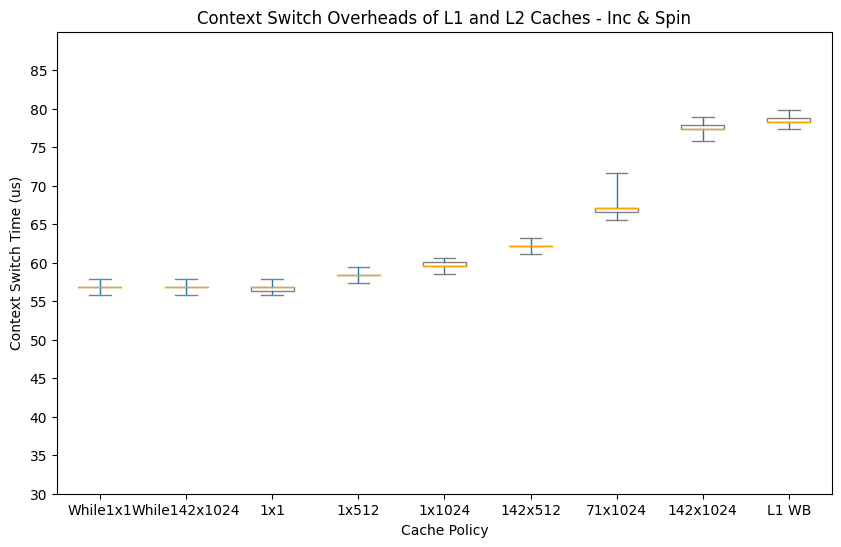

In [8]:
from analyzer_functions import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

TIMESLICE_LENGTH = 2131

def multi_boxplot(df, title, ymin=None, ymax=None, tick_step=1):
	plt.figure(figsize=(10, 6))
	df.boxplot(grid=False, 
           patch_artist=True,
           boxprops=dict(facecolor='none', color='gray'),
           flierprops=dict(markerfacecolor='red', marker='o', markersize=5),
           medianprops=dict(color='orange', linewidth=1),
		   capprops=dict(color='gray', linewidth=1),
		   whis=[0,100])
	plt.title(title)
	plt.xlabel('Cache Policy')
	plt.ylabel('Context Switch Time (us)')

	# y ticks
	if ymin is None:
		ymin = np.floor(df.min().min()) - 10
	if ymax is None:
		ymax = np.ceil(df.max().max()) + 10
	plt.ylim(ymin, ymax)
	plt.yticks(np.arange(ymin, ymax, tick_step))
	LABEL_STEP = 5
	plt.gca().set_yticks(np.arange(ymin, ymax, tick_step).tolist())
	plt.gca().set_yticklabels(np.arange(ymin, ymax, tick_step).tolist())
	# Show minor ticks (for tick marks every 1 unit)
	#plt.gca().tick_params(axis='y', which='both', length=8, width=tick_step)
	# Show minor ticks and adjust their appearance
	#plt.gca().tick_params(axis='y', which='minor', length=4, width=tick_step)
	# Add minor ticks at every unit
	#plt.gca().minorticks_on()
	# Disable minor ticks on the x-axis
	#plt.gca().tick_params(axis='x', which='minor', length=0)
	plt.show()

# read ivls
dir = 'l2/L1andL2'
# while(1)
while1_ivls = read_ivls('data/l2/L1andL2/ada-while1x1-10k.csv', single=True)
while142x1024_ivls = read_ivls('data/l2/L1andL2/ada-while142x1024-10k.csv', single=True)

# l2spin
l2spin1x1_ivls = read_ivls('data/l2spin/ada-l2spin1x1-10k.csv', single=True)
l2spin142x512_ivls = read_ivls('data/l2spin/ada-l2spin142x512-10k.csv', single=True)
l2spin71x1024_ivls = read_ivls('data/l2spin/ada-l2spin71x1024-10k.csv', single=True)
l2spin142x1024_ivls = read_ivls('data/l2spin/ada-l2spin142x1024-10k.csv', single=True)
l2spin1x512 = read_ivls('data/l2spin/ada-l2spin1x512-10k.csv', single=True)
l2spin1x1024_ivls = read_ivls('data/l2spin/ada-l2spin1x1024-10k.csv', single=True)

# L1/L2 mem fill
l1_cg_ivls = read_ivls('data/'+dir+'/ada-l1cg-10k.csv', single=True)
l1_wb_ivls = read_ivls('data/'+dir+'/ada-l1wb-10k.csv', single=True)
l1_wt_ivls = read_ivls('data/'+dir+'/ada-l1wt-10k.csv', single=True)
l2_cg_ivls = read_ivls('data/'+dir+'/ada-l2cg-10k.csv', single=True)
l2_wb_ivls = read_ivls('data/'+dir+'/ada-l2wb-10k.csv', single=True)
l2_wt_ivls = read_ivls('data/'+dir+'/ada-l2wt-10k.csv', single=True)

# get overhead
# while (1)
while1 = get_overhead(while1_ivls, TIMESLICE_LENGTH)
while142x1024 = get_overhead(while142x1024_ivls, TIMESLICE_LENGTH)

# l2 spin
l2_spin1x1 = get_overhead(l2spin1x1_ivls, TIMESLICE_LENGTH)
l2_spin142x512 = get_overhead(l2spin142x512_ivls, TIMESLICE_LENGTH)
l2spin71x1024 = get_overhead(l2spin71x1024_ivls, TIMESLICE_LENGTH)
l2_spin142x1024 = get_overhead(l2spin142x1024_ivls, TIMESLICE_LENGTH)
l2_spin1x512 = get_overhead(l2spin1x512, TIMESLICE_LENGTH)
l2_spin1x1024 = get_overhead(l2spin1x1024_ivls, TIMESLICE_LENGTH)

# L1/L2 mem fill
l1_cg = get_overhead(l1_cg_ivls, TIMESLICE_LENGTH)
l1_wb = get_overhead(l1_wb_ivls, TIMESLICE_LENGTH)
l1_wt = get_overhead(l1_wt_ivls, TIMESLICE_LENGTH)
l2_cg = get_overhead(l2_cg_ivls, TIMESLICE_LENGTH)
l2_wb = get_overhead(l2_wb_ivls, TIMESLICE_LENGTH)
l2_wt = get_overhead(l2_wt_ivls, TIMESLICE_LENGTH)

data = {
	'While1x1': while1,
	'While142x1024': while1,
	'1x1': l2_spin1x1,
	'1x512': l2_spin1x512,
	'1x1024': l2_spin1x1024,
	'142x512': l2_spin142x512,
	'71x1024': l2spin71x1024,
	'142x1024': l2_spin142x1024,
	'L1 WB': l1_wb,
}

def plot_dir(title, data, lower=30, upper=150, tick_step=1):
	df = pd.DataFrame(data)
	multi_boxplot(df, 'Context Switch Overheads of L1 and L2 Caches - '+title, lower, upper, tick_step=tick_step)

plot_dir('Inc & Spin', data, lower=30, upper=90, tick_step=5)

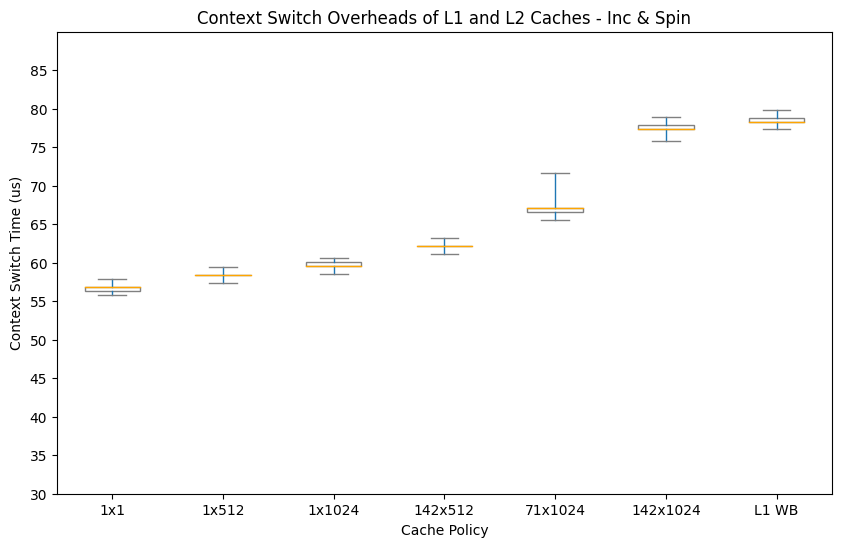

In [9]:
data = {
	#'While1x1': while1,
	#'While142x1024': while1,
	'1x1': l2_spin1x1,
	'1x512': l2_spin1x512,
	'1x1024': l2_spin1x1024,
	'142x512': l2_spin142x512,
	'71x1024': l2spin71x1024,
	'142x1024': l2_spin142x1024,
	'L1 WB': l1_wb,
}
plot_dir('Inc & Spin', data, lower=30, upper=90, tick_step=5)